In [42]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [43]:
root = '/media/sunr/C40AA1B70AA1A740/data/InfoInteg/data_newDeconv'
mname, datexp, blk = 'VG29', '2025_10_10', '2'

In [58]:
from scipy.stats import zscore

beh = np.load(os.path.join(root, 'beh', 'Beh_sup_train1_before_learning.npy'), allow_pickle=1).item()[f'{mname}_{datexp}_{blk}']
print(beh['ft'].shape)  # (frames, )
print(beh.keys())

spks = np.load(os.path.join(root, 'spk', f'{mname}_{datexp}_{blk}_neural_data.npy'), allow_pickle=1).item()['spks']
spks = np.vstack(spks)  
print(f'Loaded {mname}_{datexp}_{blk} spks with shape {spks.shape}') # shape[0] should be (neurons, frame)
nfr = spks.shape[1]
spks = spks[:, beh['istim'][:nfr] >= 2]
spks = zscore(spks, axis=1)
print(f'aligned spks shape: {spks.shape}')

(17724,)
dict_keys(['ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_GraySpc', 'ft_CorrSpc', 'istim', 'ntrials', 'stim_id', 'UniqWalls', 'WallName', 'RewPos', 'SoundPos', 'ft', 'ft_RunSpeed', 'ft_Pos', 'ft_PosCum', 'ft_move', 'ft_isMoving', 'ft_WallID', 'SoundFr', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'LickTime', 'LickPos', 'Lick_wallName', 'LickTrind'])
Loaded VG29_2025_10_10_2 spks with shape (47752, 17724)
aligned spks shape: (47752, 17724)


In [45]:
#@title Rastermap model
from rastermap import Rastermap, utils

def fit_rastermap_model(spks):
    """
    Fit the Rastermap model to the spike data.
    """
    model = Rastermap(n_clusters=100, n_PCs=200, 
                      time_lag_window=10, locality=0.75).fit(spks)
    y = model.embedding  # neurons x 1
    isort = model.isort
    cc_nodes = model.cc  # correlation matrix of cluster centers
    return model, y, isort, cc_nodes

model, y, isort, cc_nodes = fit_rastermap_model(spks)


# superneurons
bin_size = 100
sn = utils.bin1d(spks[isort], bin_size, axis=0)
sn = zscore(sn, axis=1)  # z-score again

2025-10-10 21:15:59,762 [INFO] normalizing data across axis=1
2025-10-10 21:16:03,728 [INFO] projecting out mean along axis=0
2025-10-10 21:16:07,734 [INFO] data normalized, 7.97sec
2025-10-10 21:16:07,737 [INFO] sorting activity: 47752 valid samples by 17724 timepoints
2025-10-10 21:16:14,065 [INFO] n_PCs = 200 computed, 14.30sec
2025-10-10 21:16:18,525 [INFO] 100 clusters computed, time 18.76sec
2025-10-10 21:16:23,247 [INFO] clusters sorted, time 23.49sec
2025-10-10 21:16:23,704 [INFO] clusters upsampled, time 23.94sec
2025-10-10 21:16:24,788 [INFO] rastermap complete, time 25.03sec


In [71]:
from matplotlib.colors import ListedColormap

def rastermap_with_beh_variables2(spks, sn, isort, bin_size, beh, time_window=(0, 520)):
    """
    Create an interactive rastermap plot with behavior variables.
    beh variables:
        beh['ft_WallID']: the corridor each neural frame belongs to
        beh['ft_RunSpeed']: running speed for each neural frame
        beh['RewardFr']: neural frame when reward was delivered, length=ntrials, NaN means trial without reward being delivered
        beh['StartFr']: neural frame when animal enter each corridor
        beh['GrayFr']: neural frame when animal enter gray space
        beh['EndFr']: neural frame when animal ran out of a corridor
        beh['LickFr']: neural frame when animal licked
        beh['SoundFr']: neural frame when sound cue was delivered
    """
    cmap_emb = ListedColormap(plt.get_cmap("gist_ncar")(np.linspace(0.05, 0.95), 100))
    kp_colors = np.array([[0.55,0.55,0.55], [0.,0.,1], [0.8,0,0], [1.,0.4,0.2], [0,0.6,0.4], [0.2,1,0.5]])
    ccolor = [[0,0,0.8], [0.7,0.7,0], [0,1,0], [0.8,0,0]]  # Corridor colors
    ltr = string.ascii_lowercase
    fs_title = 16

    # Main panel: Neural activity raster
    fig = plt.figure(figsize=(12, 8))
    
    xmin, xmax = time_window
    nn, nfr = sn.shape
    xr = xmax - xmin
    padding = 0.025
    
    # Create main axes using subplot for better control
    # Main raster plot takes up most of the space
    ax_main = plt.subplot2grid((8, 1), (0, 0), rowspan=6, fig=fig)
    
    # Raster plot
    ax_main.imshow(sn[:, xmin:xmax], aspect='auto', cmap='gray_r', vmin=0, vmax=2)
    ax_main.set_ylim([0, nn*(1+padding)])
    #ax_main.invert_yaxis()
    ax_main.set_title(f"Neural activity in Frame {xmin} to {xmax}", fontsize=fs_title)
    ax_main.set_ylabel("Neurons (sorted)")
    
    # Add corridor colors to raster
    corridor_starts = beh['StartFr']
    GrayFr = beh['GrayFr']
    corridor_widths = GrayFr - corridor_starts
    for n in range(len(corridor_starts)):
        if (corridor_starts[n]+corridor_widths[n] < xmax and 
                corridor_starts[n] >= xmin):
            corr_fr = int(corridor_starts[n]+3) # remove potential boundary effects
            corr_type = beh['ft_WallID'][:nfr][corr_fr]
            if corr_type == 'kiwi':
                icorr = 2
            elif corr_type == 'mkiwi':
                icorr = 3
            elif corr_type == 'stone':
                icorr = 0
            elif corr_type == 'mstone':
                icorr = 1
            else:  
                continue  # skip if corridor type is not recognized
            #icorr = 1 if corr_type == 'rock1' else 0
            start = max(0, corridor_starts[n] - xmin)
            width = min(corridor_widths[n], xmax - xmin - start)
            ax_main.add_patch(
                plt.Rectangle((start, 0), width, nn, color=ccolor[icorr], alpha=0.1))
            ax_main.legend(
                [plt.Rectangle((0, 0), 1, 1, color=ccolor[i], alpha=0.1) for i in range(len(ccolor))],
                ['stone', 'mstone', 'kiwi', 'mkiwi'],
                loc='upper right',
                fontsize=fs_title,
                title='Corridors',
                title_fontsize=fs_title
            )
    
    # Add reward events
    if 'RewardFr' in beh:
        reward_inds = beh['RewardFr']
        for n in range(len(reward_inds)):
            if reward_inds[n] >= xmin and reward_inds[n] < xmax:
                start = int(reward_inds[n] - xmin)
                ax_main.add_patch(
                    plt.Rectangle((start, 0), 1, nn, color='g', alpha=1)) 
                
    if 'SoundFr' in beh:
        sound_inds = beh['SoundFr']
        for n in range(len(sound_inds)):
            if sound_inds[n] >= xmin and sound_inds[n] < xmax:
                start = int(sound_inds[n] - xmin)
                ax_main.add_patch(
                    plt.Rectangle((start, 0), 1, nn, color=[1.,0.6,0], alpha=1))
    
    # Running speed panel - aligned with raster plot
    ax_run = plt.subplot2grid((8, 1), (7, 0), fig=fig, sharex=ax_main, rowspan=1)
    if 'ft_RunSpeed' in beh:
        run = beh['ft_RunSpeed'][:nfr]
        ax_run.fill_between(np.arange(0, xr), run[xmin:xmax], color=kp_colors[0])
        ax_run.set_xlim([0, xr])
        ax_run.set_ylim([0, np.percentile(run[xmin:xmax], 99)])
        ax_run.axis("off")
        ax_run.text(0, 1, "running speed", transform=ax_run.transAxes, color=kp_colors[0])
        ax_run.tick_params(axis='y', labelcolor=kp_colors[0])
    
    # Behavioral events panel - aligned with raster plot and positioned below running speed
    ax_events = plt.subplot2grid((8, 1), (6, 0), fig=fig, sharex=ax_main, rowspan=1)

    if 'SoundFr' in beh:
        valid = beh['SoundFr'][~np.isnan(beh['SoundFr'])]
        sound_inds = np.rint(valid).astype(int)
        sound_inds = sound_inds[(sound_inds >= xmin) & (sound_inds < xmax)]
        ax_events.scatter(sound_inds-xmin, 0.5*np.ones(len(sound_inds)), 
                            color=[1.,0.6,0], marker='s', s=15, label='Sound')

    if 'RewardFr' in beh:
        valid = beh['RewardFr'][~np.isnan(beh['RewardFr'])]
        reward_inds = np.rint(valid).astype(int)
        reward_inds = reward_inds[(reward_inds >= xmin) & (reward_inds < xmax)]
        ax_events.scatter(reward_inds-xmin, 0*np.ones(len(reward_inds)), 
                         color='g', marker='^', s=30, label='Reward')
    
    if 'LickFr' in beh:
        valid = beh['LickFr'][~np.isnan(beh['LickFr'])]
        lick_inds = np.rint(valid).astype(int)
        lick_inds = lick_inds[(lick_inds >= xmin) & (lick_inds < xmax)]
        ax_events.scatter(lick_inds-xmin, -0.5*np.ones(len(lick_inds)), 
                         color=[1.0,0.3,0.3], marker='.', s=30, label='Lick')
    
    ax_events.set_xlim([0, xr])
    ax_events.set_ylim([-1, 1])
    ax_events.set_xlabel("Time (frames)")
    ax_events.axis("off")
    ax_events.legend(loc='center left', fontsize=10, frameon=False, bbox_to_anchor=(-0.1, 0.5))
    
    # Ensure proper alignment by sharing x-axis
    plt.setp(ax_main.get_xticklabels(), visible=False)
    plt.setp(ax_run.get_xticklabels(), visible=False)

    plt.subplots_adjust(hspace=0)
    plt.tight_layout()
    return fig

supervised test1


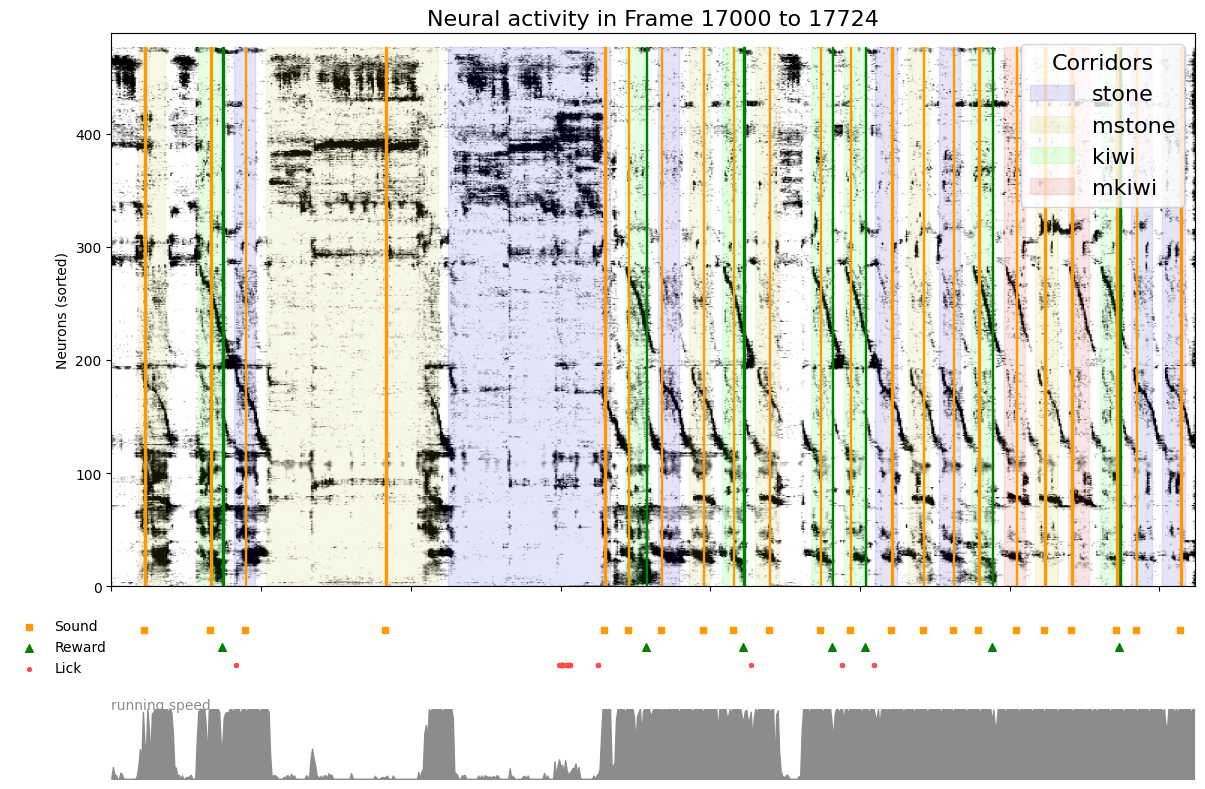

In [101]:
print("supervised test1")
fig5 = rastermap_with_beh_variables2(spks, sn,
                                   isort, bin_size, beh, time_window=(17000, 17724))      
plt.show()

In [37]:
# @title Load behavioral data
stim_id = beh['stim_id'] # 0:circle1, 1:circle2, 2:leaf1, 3:leaf2, 4:leaf3
ntrials, uniqW, WallN = beh['ntrials'], beh['UniqWalls'], beh['WallName']

#lick_fr = beh['LickFr'] # frame with lick
#cue_fr = beh['SoundFr'] # frame with cue
stim_fr = beh['ft_WallID'] # trial stimulus of each frame
pos_fr = beh['ft_Pos'] # position of each frame inside corridor
cum_pos_fr = beh['ft_PosCum']
VR_move = beh['ft_move']>0 # frames with virtual scene moving

name_stim1 = uniqW[stim_id==2][0] # name of stimulus 1; rewarded stimulus (leaf1) for supervised experiment
name_stim2 = uniqW[stim_id==0][0] # name of stimulus 2; non-rewarded stimulus (circle1) for supervised experiment
name_stim3 = uniqW[stim_id==3][0] # name of stimulus 3; non-rewarded stimulus (leaf2) for supervised experiment
name_stim4 = uniqW[stim_id==1][0] # name of stimulus 4; non-rewarded stimulus (circle2) for supervised experiment
stim1_tr = WallN==name_stim1
stim2_tr = WallN==name_stim2
stim3_tr = WallN==name_stim3
stim4_tr = WallN==name_stim4

# get index of frame within stimulus 1 (0-40 is within texture area, 40-60 is gray space)
stim1_idx = (stim_fr==name_stim1) & (pos_fr<0.4)
stim2_idx = (stim_fr==name_stim2) & (pos_fr<0.4)
stim3_idx = (stim_fr==name_stim3) & (pos_fr<0.4)
stim4_idx = (stim_fr==name_stim4) & (pos_fr<0.4)
gray_idx = ((stim_fr==name_stim1) | (stim_fr==name_stim2)) | (stim_fr==name_stim3) | (stim_fr==name_stim4) & (pos_fr>=0.4)

Text(0.5, 0, 'frames')

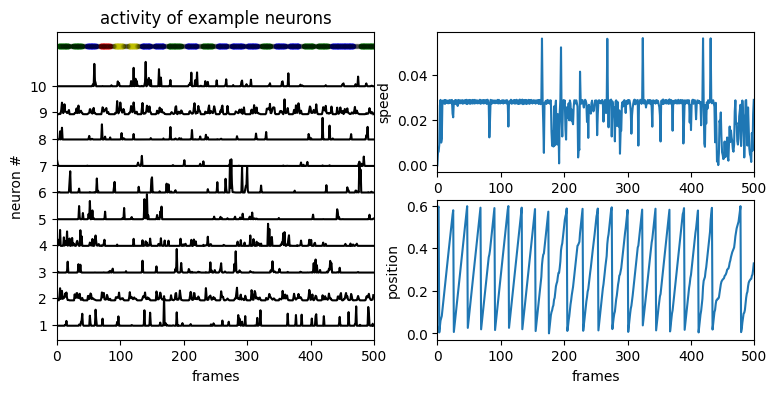

In [67]:
# @title Show example neural activity
nneu = 10
nfr = 500

fig = plt.figure(figsize=(9, 4))
plt.subplot(1,2,1)
plt.plot(spks[1000:nneu+1000, :nfr].T + np.arange(nneu)*10, 'k-')

plt.plot(np.where(stim1_idx)[0], np.zeros(stim1_idx.sum()) + nneu*10 + 5, 'g.') # green means inside stimulus 1
plt.plot(np.where(stim2_idx)[0], np.zeros(stim2_idx.sum()) + nneu*10 + 5, 'b.') # blue means inside stimulus 2
plt.plot(np.where(stim3_idx)[0], np.zeros(stim3_idx.sum()) + nneu*10 + 5, 'r.') # red means inside stimulus 3
plt.plot(np.where(stim4_idx)[0], np.zeros(stim4_idx.sum()) + nneu*10 + 5, 'y.') # yellow means inside stimulus 4
plt.plot(np.where(gray_idx)[0], np.zeros(gray_idx.sum()) + nneu*10 + 5, 'k.', alpha=0.1) # grey means inside grey space

plt.yticks(np.arange(nneu)*10, np.arange(nneu)+1)
plt.xlim([0, 500])
plt.ylabel('neuron #')
plt.xlabel('frames')
plt.title('activity of example neurons')

plt.subplot(2,2,2)
plt.plot(beh['ft_RunSpeed'][:nfr])
plt.xlim([0, 500])
plt.ylabel('speed')

plt.subplot(2,2,4)
plt.plot(pos_fr[:nfr])
plt.xlim([0, 500])
plt.ylabel('position')
plt.xlabel('frames')
